<a href="https://colab.research.google.com/github/Viresh2408/California-House-Prediction-System/blob/main/California_House_Prediction_System.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [6]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

In [7]:
from sklearn.datasets import fetch_california_housing

In [8]:
fetch=fetch_california_housing()

In [9]:
fetch.feature_names

['MedInc',
 'HouseAge',
 'AveRooms',
 'AveBedrms',
 'Population',
 'AveOccup',
 'Latitude',
 'Longitude']

In [10]:
dataset=pd.DataFrame(fetch.data,columns=fetch.feature_names)

In [11]:
print(dataset.head())

   MedInc  HouseAge  AveRooms  AveBedrms  Population  AveOccup  Latitude  \
0  8.3252      41.0  6.984127   1.023810       322.0  2.555556     37.88   
1  8.3014      21.0  6.238137   0.971880      2401.0  2.109842     37.86   
2  7.2574      52.0  8.288136   1.073446       496.0  2.802260     37.85   
3  5.6431      52.0  5.817352   1.073059       558.0  2.547945     37.85   
4  3.8462      52.0  6.281853   1.081081       565.0  2.181467     37.85   

   Longitude  
0    -122.23  
1    -122.22  
2    -122.24  
3    -122.25  
4    -122.25  


In [12]:
dataset["Price"]=fetch.target

In [13]:
dataset.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 20640 entries, 0 to 20639
Data columns (total 9 columns):
 #   Column      Non-Null Count  Dtype  
---  ------      --------------  -----  
 0   MedInc      20640 non-null  float64
 1   HouseAge    20640 non-null  float64
 2   AveRooms    20640 non-null  float64
 3   AveBedrms   20640 non-null  float64
 4   Population  20640 non-null  float64
 5   AveOccup    20640 non-null  float64
 6   Latitude    20640 non-null  float64
 7   Longitude   20640 non-null  float64
 8   Price       20640 non-null  float64
dtypes: float64(9)
memory usage: 1.4 MB


In [14]:
dataset.describe()

,MedInc,HouseAge,AveRooms,AveBedrms,Population,AveOccup,Latitude,Longitude,Price
count,20640.000000,20640.000000,20640.000000,20640.000000,20640.000000,20640.000000,20640.000000,20640.000000,20640.000000
mean,3.870671,28.639486,5.429000,1.096675,1425.476744,3.070655,35.631861,-119.569704,2.068558
std,1.899822,12.585558,2.474173,0.473911,1132.462122,10.386050,2.135952,2.003532,1.153956
min,0.499900,1.000000,0.846154,0.333333,3.000000,0.692308,32.540000,-124.350000,0.149990
25%,2.563400,18.000000,4.440716,1.006079,787.000000,2.429741,33.930000,-121.800000,1.196000
50%,3.534800,29.000000,5.229129,1.048780,1166.000000,2.818116,34.260000,-118.490000,1.797000
75%,4.743250,37.000000,6.052381,1.099526,1725.000000,3.282261,37.710000,-118.010000,2.647250
max,15.000100,52.000000,141.909091,34.066667,35682.000000,1243.333333,41.950000,-114.310000,5.000010


In [15]:
dataset.isnull().sum()

,0
MedInc,0
HouseAge,0
AveRooms,0
AveBedrms,0
Population,0
AveOccup,0
Latitude,0
Longitude,0
Price,0


In [16]:
dataset

,MedInc,HouseAge,AveRooms,AveBedrms,Population,AveOccup,Latitude,Longitude,Price
0,8.3252,41.0,6.984127,1.023810,322.0,2.555556,37.88,-122.23,4.526
1,8.3014,21.0,6.238137,0.971880,2401.0,2.109842,37.86,-122.22,3.585
2,7.2574,52.0,8.288136,1.073446,496.0,2.802260,37.85,-122.24,3.521
3,5.6431,52.0,5.817352,1.073059,558.0,2.547945,37.85,-122.25,3.413
4,3.8462,52.0,6.281853,1.081081,565.0,2.181467,37.85,-122.25,3.422
...,...,...,...,...,...,...,...,...,...
20635,1.5603,25.0,5.045455,1.133333,845.0,2.560606,39.48,-121.09,0.781
20636,2.5568,18.0,6.114035,1.315789,356.0,3.122807,39.49,-121.21,0.771
20637,1.7000,17.0,5.205543,1.120092,1007.0,2.325635,39.43,-121.22,0.923
20638,1.8672,18.0,5.329513,1.171920,741.0,2.123209,39.43,-121.32,0.847


In [17]:
dataset.corr()

,MedInc,HouseAge,AveRooms,AveBedrms,Population,AveOccup,Latitude,Longitude,Price
MedInc,1.000000,-0.119034,0.326895,-0.062040,0.004834,0.018766,-0.079809,-0.015176,0.688075
HouseAge,-0.119034,1.000000,-0.153277,-0.077747,-0.296244,0.013191,0.011173,-0.108197,0.105623
AveRooms,0.326895,-0.153277,1.000000,0.847621,-0.072213,-0.004852,0.106389,-0.027540,0.151948
AveBedrms,-0.062040,-0.077747,0.847621,1.000000,-0.066197,-0.006181,0.069721,0.013344,-0.046701
Population,0.004834,-0.296244,-0.072213,-0.066197,1.000000,0.069863,-0.108785,0.099773,-0.024650
AveOccup,0.018766,0.013191,-0.004852,-0.006181,0.069863,1.000000,0.002366,0.002476,-0.023737
Latitude,-0.079809,0.011173,0.106389,0.069721,-0.108785,0.002366,1.000000,-0.924664,-0.144160
Longitude,-0.015176,-0.108197,-0.027540,0.013344,0.099773,0.002476,-0.924664,1.000000,-0.045967
Price,0.688075,0.105623,0.151948,-0.046701,-0.024650,-0.023737,-0.144160,-0.045967,1.000000


In [18]:
import seaborn as sns

<Axes: xlabel='Price', ylabel='Population'>

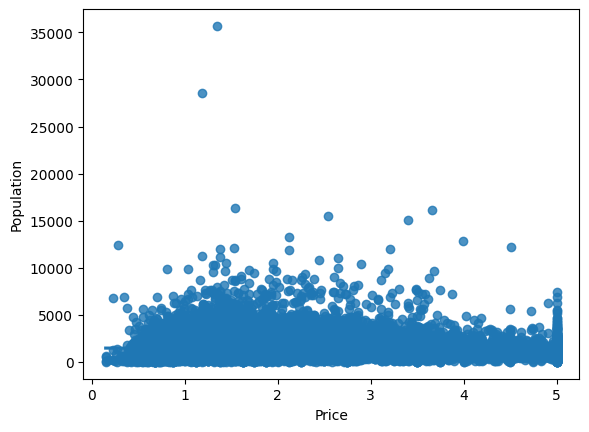

In [19]:
sns.regplot(x="Price",y="Population",data=dataset)

### ***Independent and Dependent Features***

In [20]:
X=dataset.iloc[:,:-1]
y=dataset.iloc[:,-1]

In [21]:
X

,MedInc,HouseAge,AveRooms,AveBedrms,Population,AveOccup,Latitude,Longitude
0,8.3252,41.0,6.984127,1.023810,322.0,2.555556,37.88,-122.23
1,8.3014,21.0,6.238137,0.971880,2401.0,2.109842,37.86,-122.22
2,7.2574,52.0,8.288136,1.073446,496.0,2.802260,37.85,-122.24
3,5.6431,52.0,5.817352,1.073059,558.0,2.547945,37.85,-122.25
4,3.8462,52.0,6.281853,1.081081,565.0,2.181467,37.85,-122.25
...,...,...,...,...,...,...,...,...
20635,1.5603,25.0,5.045455,1.133333,845.0,2.560606,39.48,-121.09
20636,2.5568,18.0,6.114035,1.315789,356.0,3.122807,39.49,-121.21
20637,1.7000,17.0,5.205543,1.120092,1007.0,2.325635,39.43,-121.22
20638,1.8672,18.0,5.329513,1.171920,741.0,2.123209,39.43,-121.32


In [22]:
y

,Price
0,4.526
1,3.585
2,3.521
3,3.413
4,3.422
...,...
20635,0.781
20636,0.771
20637,0.923
20638,0.847


## ***Train-Test Split***

In [23]:
from numpy.random import rand
from sklearn.model_selection import train_test_split
X_train,X_test,y_train,y_test=train_test_split(X,y,test_size=0.3,random_state=36)

In [24]:
X_train

,MedInc,HouseAge,AveRooms,AveBedrms,Population,AveOccup,Latitude,Longitude
25,2.4038,41.0,4.495798,1.033613,317.0,2.663866,37.85,-122.28
16747,4.0833,35.0,4.789855,0.929952,1577.0,3.809179,37.69,-122.46
8309,5.1508,15.0,5.317173,1.078855,3333.0,1.946846,33.77,-118.11
15553,3.0915,31.0,4.812646,1.107728,1326.0,3.105386,33.11,-117.07
13075,3.6563,19.0,5.125000,0.979167,1346.0,2.804167,38.59,-121.29
...,...,...,...,...,...,...,...,...
5769,2.8342,35.0,3.923077,1.067155,2401.0,2.931624,34.16,-118.30
986,10.3203,43.0,5.428571,0.952381,83.0,1.976190,37.72,-121.85
7329,2.9844,36.0,3.582857,1.011429,834.0,4.765714,33.98,-118.17
19368,3.9336,18.0,6.188406,1.207729,1128.0,2.724638,38.38,-122.93


In [25]:
X_test

,MedInc,HouseAge,AveRooms,AveBedrms,Population,AveOccup,Latitude,Longitude
13210,4.0096,5.0,5.061294,1.017026,2028.0,2.301930,34.04,-117.69
12777,1.8611,42.0,4.751381,1.055249,1069.0,2.953039,38.64,-121.42
5288,4.1750,27.0,4.574844,1.073805,1725.0,1.793139,34.05,-118.47
5632,2.4500,41.0,3.536585,1.032520,1384.0,3.750678,33.75,-118.28
17603,4.1406,44.0,5.289817,1.033943,908.0,2.370757,37.29,-121.88
...,...,...,...,...,...,...,...,...
13410,3.6602,18.0,5.455840,1.068376,2767.0,3.941595,34.08,-117.46
6368,6.5254,38.0,6.821510,0.988558,1063.0,2.432494,34.18,-117.99
4372,4.0602,44.0,4.811287,1.031746,1227.0,2.164021,34.10,-118.28
15307,1.9562,18.0,3.409091,1.335664,650.0,2.272727,33.19,-117.37


# ***Standarized Scaler***

In [26]:
from sklearn.preprocessing import StandardScaler
scaler=StandardScaler()

In [27]:
X_train=scaler.fit_transform(X_train)

In [28]:
X_train

array([[-0.76747759,  0.97600937, -0.36084838, ..., -0.0372651 ,
         1.03305272, -1.34834656],
       [ 0.10764889,  0.49917096, -0.24835641, ...,  0.05523322,
         0.95827682, -1.43808896],
       [ 0.66388438, -1.09029041, -0.04662997, ..., -0.09517339,
        -0.87373277,  0.73068569],
       ...,
       [-0.46494801,  0.57864403, -0.71009577, ...,  0.13248539,
        -0.7755894 ,  0.70077156],
       [ 0.02964565, -0.85187121,  0.28666184, ..., -0.03235699,
         1.28074789, -1.67241633],
       [ 0.48297107, -0.69292507, -0.02642086, ..., -0.07755471,
         0.95827682, -1.25361847]])

In [29]:
X_test=scaler.transform(X_test)

In [30]:
X_test

array([[ 0.06924649, -1.8850211 , -0.14451694, ..., -0.06649594,
        -0.74754844,  0.94008462],
       [-1.05025886,  1.05548244, -0.26307466, ..., -0.01391076,
         1.40225873, -0.91957732],
       [ 0.15543043, -0.13661359, -0.33060928, ..., -0.1075871 ,
        -0.74287494,  0.55120089],
       ...,
       [ 0.09561232,  1.21442858, -0.2401574 , ..., -0.07763377,
        -0.71950747,  0.64592898],
       [-1.0007057 , -0.85187121, -0.77657037, ..., -0.06885439,
        -1.14479541,  1.09962666],
       [-0.1311546 , -0.53397893,  0.15894292, ..., -0.0347139 ,
         1.28542139, -1.61757376]])

## ***Model Training***::

In [31]:
from sklearn.linear_model import LinearRegression


In [32]:
regression=LinearRegression()

In [33]:
regression.fit(X_train,y_train)

LinearRegression()

In [34]:
print(regression.coef_)

[ 0.83526622  0.12312804 -0.26275806  0.30916064 -0.00680234 -0.04027161
 -0.90920669 -0.87947923]


In [35]:
reg_pred=regression.predict(X_test)

In [36]:
reg_pred

array([1.73796664, 0.90391224, 2.45009442, ..., 2.41411064, 1.56172134,
       2.11893013])

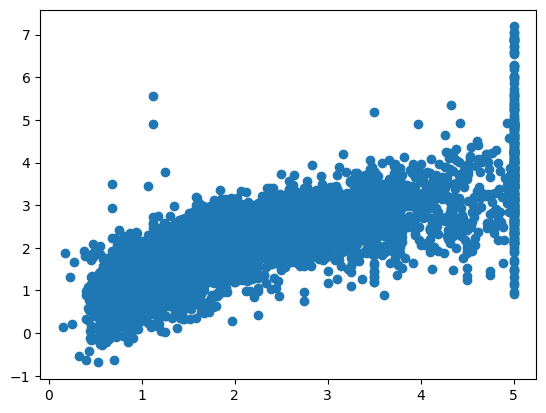

In [37]:
plt.scatter(y_test,reg_pred)


In [38]:
residuals=y_test-reg_pred

In [39]:
residuals

,Price
13210,0.088033
12777,-0.298912
5288,2.549916
5632,-0.087199
17603,0.114412
...,...
13410,-0.370388
6368,0.611259
4372,0.825889
15307,0.363279


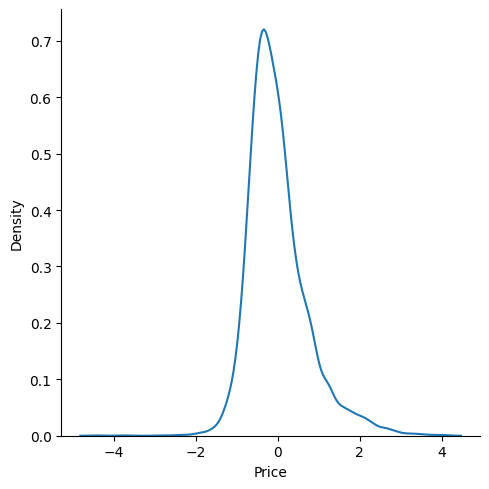

In [40]:
sns.displot(residuals,kind="kde")

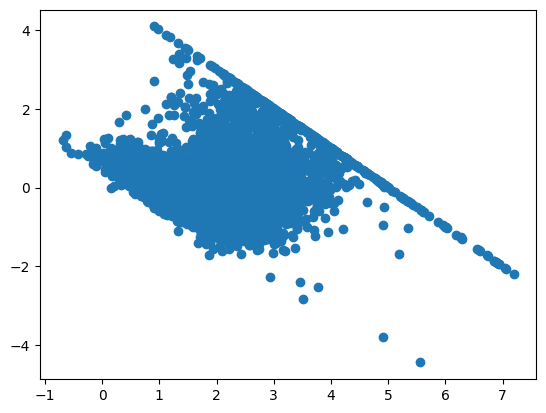

In [41]:
plt.scatter(reg_pred,residuals)

In [42]:
from sklearn.metrics import mean_squared_error
from sklearn.metrics import mean_absolute_error

In [43]:
print(mean_absolute_error(y_test,reg_pred))
print(mean_squared_error(y_test,reg_pred))


0.5399218124522563
0.5335350373729457


## ***R Square and Adjusted R Square***

In [44]:
from sklearn.metrics import r2_score
score=r2_score(y_test,reg_pred)
print(score)

0.5852986212802392


## **Adjusted R2**

In [45]:
1-(1-score)*(len(y_test)-1)/(len(y_test)-X_test.shape[1]-1)

0.5847620514872977

## **New Data Prediction**

In [46]:
fetch.data[0].reshape(1,-1)

array([[   8.3252    ,   41.        ,    6.98412698,    1.02380952,
         322.        ,    2.55555556,   37.88      , -122.23      ]])

In [47]:
scaler.transform(fetch.data[0].reshape(1,-1))

/usr/local/lib/python3.12/dist-packages/sklearn/utils/validation.py:2739: UserWarning: X does not have valid feature names, but StandardScaler was fitted with feature names
  warnings.warn(


array([[ 2.31794898,  0.97600937,  0.59106649, -0.14712813, -0.95137508,
        -0.04601248,  1.0470732 , -1.32341811]])

In [48]:
regression.predict(fetch.data[0].reshape(1,-1))

array([83.31996523])

## **Pickling the Model for Deployment**

In [49]:
import pickle

In [50]:
pickle.dump(regression,open('regmodel.pkl','wb'))

In [51]:
pickled_model=pickle.load(open('regmodel.pkl','rb'))


In [53]:
pickled_model.predict(fetch.data[0].reshape(1,-1))

array([83.31996523])